In [1]:
# Import required classes from LangGraph
# StateGraph  -> Used to create a workflow/graph
# START       -> Special starting point of the graph
# END         -> Special ending point of the graph

from langgraph.graph import StateGraph, START, END

In [2]:
# -------------------------------
# Step 1: Create Task Functions
# -------------------------------
# Each function represents one node/task in the graph.
# The "state" acts like shared data flowing between nodes.

def tastA(state):
  
  # This line executes when Node A runs
  print('A started working')
  
  # Return updated/current state to next node
  return state


def tastB(state):
  
  # Executes when Node B runs
  print('B started working')
  
  # Pass state to next node
  return state


def tastC(state):
  
  # Executes when Node C runs
  print('C started working')
  
  # Return state to graph
  return state


# ------------------------------------
# Step 2: Create Empty State Graph
# ------------------------------------
# dict means graph state will be stored in dictionary format

graph = StateGraph(dict)


# ------------------------------------
# Step 3: Add Nodes into the Graph
# ------------------------------------
# Syntax:
# graph.add_node("Node_Name", function_name)

graph.add_node("A", tastA)
graph.add_node('B', tastB)
graph.add_node('C', tastC)


# ------------------------------------
# Step 4: Connect Nodes using Edges
# ------------------------------------
# Flow:
# START -> A -> B -> C -> END

# graph.add_edge(START, 'A')  Tells graph execution should begin from Node A
graph.add_edge('A', 'B')
graph.add_edge('B', 'C')
graph.add_edge('C', END)


# ------------------------------------
# Step 5: Define Entry Point
# ------------------------------------
# Tells graph execution should begin from Node A

graph.set_entry_point('A')


# ------------------------------------
# Step 6: Compile the Graph
# ------------------------------------
# Converts graph structure into executable graph

graph = graph.compile()


# ------------------------------------
# Step 7: Execute the Graph
# ------------------------------------
# invoke({}) starts execution with empty state

graph.invoke({})


# Uncomment below line to inspect graph object
# graph

A started working
B started working
C started working


{}

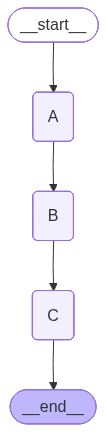

In [3]:
# Import display utilities from IPython
# Image   -> Used to show graph image
# display -> Used to render output in notebook

from IPython.display import display, Image


# ------------------------------------
# Visualize the Graph Structure
# ------------------------------------
# draw_mermaid_png() creates graph diagram
# display() shows the generated image inside notebook

display(Image(graph.get_graph().draw_mermaid_png()))